# MSCS-634: Project Deliverable 2: Regression Modeling and Performance Evaluation

**Name:** Oishani Ganguly

**Course:** MSCS-634: Advanced Big Data and Data Mining

**Dataset:** Customer Shopping Trends Dataset 
 
**Source:** https://www.kaggle.com/datasets/iamsouravbanerjee/customer-shopping-trends-dataset

---
## Overview

Building on the data cleaning and EDA work in Deliverable 1, this deliverable develops and evaluates regression models to predict **Purchase Amount (USD)** — the dollar value of each customer transaction.

The workflow is:
1. Re-apply Deliverable 1 cleaning steps (drop `Preferred Payment Method`, encode binary columns)
2. Perform feature engineering to create new predictive features
3. Train four regression models: Linear Regression, Ridge, Lasso, and Random Forest
4. Evaluate each model using R², MSE, and RMSE with 5-fold cross-validation
5. Visualize and compare model performance

**Note on expectations:** Deliverable 1 EDA showed that all numeric features have near-zero correlation with Purchase Amount, and that the target is uniformly distributed between $20 and $100. This is a property of the synthetic dataset design. As a result, R² scores across all models are expected to be low — this is an authentic and important finding, not a modeling failure, and it is addressed directly in the analysis.

---
## 1. Setup and Data Loading

In [101]:
# Core libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
import warnings

# Scikit-learn: preprocessing, models, evaluation
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split, cross_val_score, KFold
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.pipeline import Pipeline

warnings.filterwarnings('ignore')
sns.set_theme(style='whitegrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 130
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', '{:.4f}'.format)
np.random.seed(42)

print('All libraries loaded.')

All libraries loaded.


In [102]:
# Load the original dataset
df = pd.read_csv('shopping_trends.csv')
print(f'Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns')
df.head(3)

Loaded: 3,900 rows x 19 columns


,Customer ID,Age,Gender,Item Purchased,Category,Purchase Amount (USD),Location,Size,Color,Season,Review Rating,Subscription Status,Payment Method,Shipping Type,Discount Applied,Promo Code Used,Previous Purchases,Preferred Payment Method,Frequency of Purchases
0,1,55,Male,Blouse,Clothing,53,Kentucky,L,Gray,Winter,3.1000,Yes,Credit Card,Express,Yes,Yes,14,Venmo,Fortnightly
1,2,19,Male,Sweater,Clothing,64,Maine,L,Maroon,Winter,3.1000,Yes,Bank Transfer,Express,Yes,Yes,2,Cash,Fortnightly
2,3,50,Male,Jeans,Clothing,73,Massachusetts,S,Maroon,Spring,3.1000,Yes,Cash,Free Shipping,Yes,Yes,23,Credit Card,Weekly


---
## 2. Re-apply Deliverable 1 Cleaning

We reproduce the cleaning pipeline established in Deliverable 1 before adding any new features. This ensures a consistent, reproducible starting point.

In [103]:
# ── Deliverable 1 cleaning pipeline ─────────────────────────────────────────

# 1. Standardize all string columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
for col in cat_cols:
    df[col] = df[col].str.strip().str.title()

# 2. Drop Preferred Payment Method (agreed with Payment Method only 15.8% of the time)
df.drop(columns=['Preferred Payment Method'], inplace=True)

# 3. Binary encode Yes/No columns
df['Subscription_Enc'] = (df['Subscription Status'] == 'Yes').astype(int)
df['Discount_Enc']     = (df['Discount Applied']    == 'Yes').astype(int)
df['PromoCode_Enc']    = (df['Promo Code Used']      == 'Yes').astype(int)

print(f'Post-cleaning shape: {df.shape}')
print('Cleaning complete — Preferred Payment Method dropped, binary columns encoded.')

Post-cleaning shape: (3900, 21)
Cleaning complete — Preferred Payment Method dropped, binary columns encoded.


---
## 3. Feature Engineering

Feature engineering transforms raw columns into representations that better capture the patterns a model can learn from. The goal is to give the models richer signal than the raw attributes alone provide.

Steps performed:
1. **Drop non-predictive columns** — identifiers and high-cardinality columns with no signal for purchase amount
2. **Ordinal encode Frequency of Purchases** — convert purchase cadence to a numeric scale representing spend intensity
3. **One-hot encode remaining categoricals** — convert nominal columns to numeric without implying order
4. **Create interaction features** — multiply related binary flags to capture joint effects
5. **Create an Engagement Score** — a composite feature summarizing customer loyalty signals

In [104]:
# ── Step 1: Drop non-predictive columns ──────────────────────────────────────
#
# Customer ID   — row identifier, carries no signal
# Item Purchased — 25 unique values; too granular and redundant with Category
# Location       — 50 US states; high cardinality with no geographic aggregation available
# Color          — 25 unique values; cosmetic attribute unlikely to drive purchase amount
# Subscription Status / Discount Applied / Promo Code Used
#               — already encoded as *_Enc columns; drop original string versions

cols_to_drop = [
    'Customer ID', 'Item Purchased', 'Location', 'Color',
    'Subscription Status', 'Discount Applied', 'Promo Code Used'
]
df_fe = df.drop(columns=cols_to_drop).copy()

print(f'Shape after dropping non-predictive columns: {df_fe.shape}')
print(f'Remaining columns: {list(df_fe.columns)}')

Shape after dropping non-predictive columns: (3900, 14)
Remaining columns: ['Age', 'Gender', 'Category', 'Purchase Amount (USD)', 'Size', 'Season', 'Review Rating', 'Payment Method', 'Shipping Type', 'Previous Purchases', 'Frequency of Purchases', 'Subscription_Enc', 'Discount_Enc', 'PromoCode_Enc']


In [105]:
# ── Step 2: Ordinal encode Frequency of Purchases ────────────────────────────
#
# Rationale: purchase frequency has a natural ordering by how often a customer
# shops. We map this to an integer scale (1=least frequent, 7=most frequent)
# so models can treat more-frequent shoppers as numerically distinct from less-
# frequent ones.

freq_order = {
    'Annually':       1,
    'Quarterly':      2,
    'Every 3 Months': 3,
    'Monthly':        4,
    'Fortnightly':    5,
    'Bi-Weekly':      6,
    'Weekly':         7
}
df_fe['Frequency_Ordinal'] = df_fe['Frequency of Purchases'].map(freq_order)
df_fe.drop(columns=['Frequency of Purchases'], inplace=True)

print('Frequency of Purchases encoded to ordinal scale (1=Annually … 7=Weekly):')
print(df_fe['Frequency_Ordinal'].value_counts().sort_index())

Frequency of Purchases encoded to ordinal scale (1=Annually … 7=Weekly):
Frequency_Ordinal
1    572
2    563
3    584
4    553
5    542
6    547
7    539
Name: count, dtype: int64


In [106]:
# ── Step 3: One-hot encode remaining categorical columns ─────────────────────
#
# Nominal columns (no inherent order) are one-hot encoded.
# drop_first=True removes one dummy per group to avoid multicollinearity
# (the "dummy variable trap").

ohe_cols = ['Gender', 'Category', 'Season', 'Size', 'Shipping Type', 'Payment Method']

df_fe = pd.get_dummies(df_fe, columns=ohe_cols, drop_first=True)

# Convert any boolean dummy columns to int for cleaner output
bool_cols = df_fe.select_dtypes(include='bool').columns
df_fe[bool_cols] = df_fe[bool_cols].astype(int)

print(f'Shape after one-hot encoding: {df_fe.shape}')
print(f'Columns added by OHE: {df_fe.shape[1] - 12}')

Shape after one-hot encoding: (3900, 28)
Columns added by OHE: 16


In [107]:
# ── Step 4: Interaction features ─────────────────────────────────────────────
#
# Discount_x_Promo: customers who use both discounts AND promo codes may behave
# differently from those who use only one. This interaction captures the joint effect.
#
# Age_x_PrevPurchases: an older customer with many previous purchases may represent
# a distinct high-value segment. The product of age and purchase history captures this.

df_fe['Discount_x_Promo']      = df_fe['Discount_Enc'] * df_fe['PromoCode_Enc']
df_fe['Age_x_PrevPurchases']   = df_fe['Age'] * df_fe['Previous Purchases']

print('Interaction features created:')
print(f"  Discount_x_Promo     — {df_fe['Discount_x_Promo'].value_counts().to_dict()}")
print(f"  Age_x_PrevPurchases  — min={df_fe['Age_x_PrevPurchases'].min()}, "
      f"max={df_fe['Age_x_PrevPurchases'].max()}, "
      f"mean={df_fe['Age_x_PrevPurchases'].mean():.1f}")

Interaction features created:
  Discount_x_Promo     — {0: 2223, 1: 1677}
  Age_x_PrevPurchases  — min=18, max=3500, mean=1126.1


In [108]:
# ── Step 5: Engagement Score ─────────────────────────────────────────────────
#
# A composite loyalty signal combining three independent behavioral indicators:
#   - Has a subscription (recurring commitment)
#   - Used a discount (deal-seeking behavior)
#   - Used a promo code (promotional engagement)
#
# Range 0–3. Higher scores indicate more engaged, deal-aware customers.

df_fe['Engagement_Score'] = (
    df_fe['Subscription_Enc'] +
    df_fe['Discount_Enc'] +
    df_fe['PromoCode_Enc']
)

print('Engagement Score distribution (0=least engaged, 3=most engaged):')
print(df_fe['Engagement_Score'].value_counts().sort_index())

Engagement Score distribution (0=least engaged, 3=most engaged):
Engagement_Score
0    2223
2     624
3    1053
Name: count, dtype: int64


In [109]:
# Final feature-engineered dataset overview
print(f'Final feature matrix shape: {df_fe.shape}')
print(f'\nAll columns:')
for col in df_fe.columns:
    print(f'  {col}')

Final feature matrix shape: (3900, 31)

All columns:
  Age
  Purchase Amount (USD)
  Review Rating
  Previous Purchases
  Subscription_Enc
  Discount_Enc
  PromoCode_Enc
  Frequency_Ordinal
  Gender_Male
  Category_Clothing
  Category_Footwear
  Category_Outerwear
  Season_Spring
  Season_Summer
  Season_Winter
  Size_M
  Size_S
  Size_Xl
  Shipping Type_Express
  Shipping Type_Free Shipping
  Shipping Type_Next Day Air
  Shipping Type_Standard
  Shipping Type_Store Pickup
  Payment Method_Cash
  Payment Method_Credit Card
  Payment Method_Debit Card
  Payment Method_Paypal
  Payment Method_Venmo
  Discount_x_Promo
  Age_x_PrevPurchases
  Engagement_Score


### 3.1 – Feature Correlation with Target

Before modeling, we compute each feature's Pearson correlation with `Purchase Amount (USD)` to understand which engineered features carry the most signal. This also guides feature selection and sets expectations for model performance.

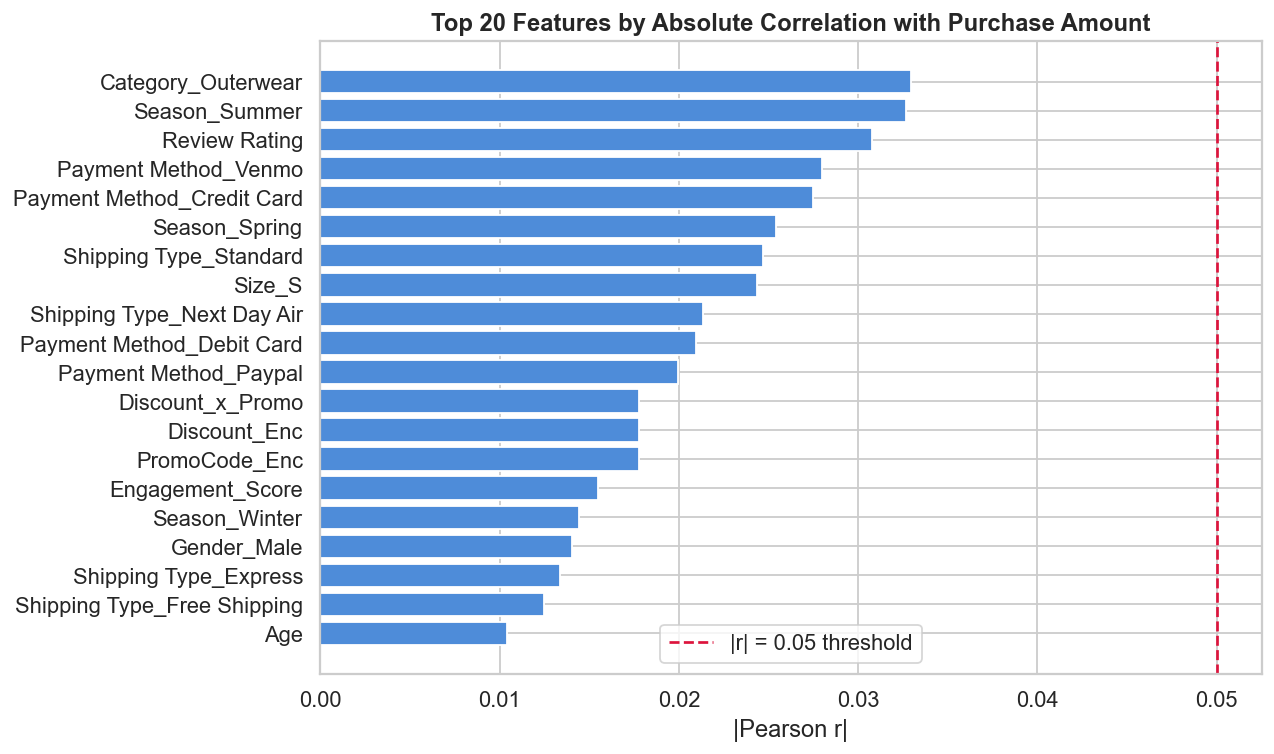

Top 10 features by |correlation| with target:
Category_Outerwear           0.0329
Season_Summer                0.0327
Review Rating                0.0308
Payment Method_Venmo         0.0280
Payment Method_Credit Card   0.0275
Season_Spring                0.0254
Shipping Type_Standard       0.0247
Size_S                       0.0243
Shipping Type_Next Day Air   0.0214
Payment Method_Debit Card    0.0209


In [110]:
target = 'Purchase Amount (USD)'
corr_with_target = (
    df_fe.corr()[target]
    .drop(target)
    .abs()
    .sort_values(ascending=False)
)

# Plot top 20 features by absolute correlation with target
top20 = corr_with_target.head(20)

fig, ax = plt.subplots(figsize=(10, 6))
colors = ['#e07b39' if v > 0.05 else '#4e8cd9' for v in top20.values]
ax.barh(top20.index[::-1], top20.values[::-1], color=colors[::-1], edgecolor='white')
ax.axvline(0.05, color='crimson', linestyle='--', lw=1.5, label='|r| = 0.05 threshold')
ax.set_title('Top 20 Features by Absolute Correlation with Purchase Amount',
             fontweight='bold')
ax.set_xlabel('|Pearson r|')
ax.legend()
plt.tight_layout()
plt.savefig('viz_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 10 features by |correlation| with target:')
print(corr_with_target.head(10).to_string())

**Insight:** As anticipated from Deliverable 1 EDA, all features show very low absolute correlation with Purchase Amount — no feature exceeds |r| = 0.05. This is a structural property of the synthetic dataset: purchase amounts were generated uniformly and largely independently of the other attributes. This finding sets realistic performance expectations for all models that follow. Low R² scores are the correct and honest result for this dataset, not a sign of modeling error.

---
## 4. Train/Test Split and Feature Scaling

The dataset is split 80/20 into training and test sets using stratification by the target's quartile bins to ensure balanced representation of the purchase amount range in both sets. StandardScaler is applied to numeric features so that regularized models (Ridge, Lasso) penalize coefficients on a common scale.

In [111]:
X = df_fe.drop(columns=[target])
y = df_fe[target]

# Stratify on quartile bins to preserve target distribution in both splits
y_bins = pd.qcut(y, q=4, labels=False)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y_bins
)

print(f'Training set:  {X_train.shape[0]:,} rows x {X_train.shape[1]} features')
print(f'Test set:      {X_test.shape[0]:,} rows x {X_test.shape[1]} features')
print(f'\nTarget distribution — Train: mean={y_train.mean():.2f}, std={y_train.std():.2f}')
print(f'Target distribution — Test:  mean={y_test.mean():.2f}, std={y_test.std():.2f}')

Training set:  3,120 rows x 30 features
Test set:      780 rows x 30 features

Target distribution — Train: mean=59.75, std=23.74
Target distribution — Test:  mean=59.82, std=23.47


In [112]:
# Fit scaler on training data only; apply to both sets (prevents data leakage)
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

print('StandardScaler applied: features normalized to zero mean, unit variance.')
print(f'Mean of first feature after scaling (train): {X_train_scaled[:, 0].mean():.6f}')
print(f'Std  of first feature after scaling (train): {X_train_scaled[:, 0].std():.6f}')

StandardScaler applied: features normalized to zero mean, unit variance.
Mean of first feature after scaling (train): -0.000000
Std  of first feature after scaling (train): 1.000000


---
## 5. Regression Models

Four models are trained and compared:

| Model | Type | Key Characteristic |
|---|---|---|
| **Linear Regression** | Parametric | Baseline; no regularization |
| **Ridge Regression** | Parametric + L2 regularization | Shrinks all coefficients; handles multicollinearity |
| **Lasso Regression** | Parametric + L1 regularization | Can zero out irrelevant features (implicit selection) |
| **Random Forest** | Non-parametric, ensemble | Captures non-linear relationships; robust to noise |

### 5.1 – Model 1: Linear Regression (Baseline)

Ordinary Least Squares (OLS) linear regression minimizes the sum of squared residuals. It assumes a linear relationship between each feature and the target and applies no regularization. This serves as the baseline against which regularized and non-linear models are compared.

In [113]:
lr = LinearRegression()
lr.fit(X_train_scaled, y_train)
y_pred_lr = lr.predict(X_test_scaled)

r2_lr   = r2_score(y_test, y_pred_lr)
mse_lr  = mean_squared_error(y_test, y_pred_lr)
rmse_lr = np.sqrt(mse_lr)

print('=== Linear Regression (Baseline) ===')
print(f'  R²   : {r2_lr:.4f}')
print(f'  MSE  : {mse_lr:.4f}')
print(f'  RMSE : {rmse_lr:.4f}')

=== Linear Regression (Baseline) ===
  R²   : -0.0070
  MSE  : 553.8257
  RMSE : 23.5335


### 5.2 – Model 2: Ridge Regression (L2 Regularization)

Ridge adds an L2 penalty (sum of squared coefficients × α) to the OLS loss function. This shrinks all coefficients toward zero but never fully eliminates them. It is particularly effective when many features have small but non-zero effects. The alpha hyperparameter controls regularization strength.

In [114]:
# Tune alpha via cross-validation on training set
alphas = [0.01, 0.1, 1.0, 10.0, 50.0, 100.0]
ridge_cv_scores = []
kf = KFold(n_splits=5, shuffle=True, random_state=42)

for a in alphas:
    scores = cross_val_score(Ridge(alpha=a), X_train_scaled, y_train,
                             cv=kf, scoring='r2')
    ridge_cv_scores.append(scores.mean())

best_alpha_ridge = alphas[np.argmax(ridge_cv_scores)]
print(f'Ridge CV R² by alpha: {dict(zip(alphas, [round(s,4) for s in ridge_cv_scores]))}')
print(f'Best alpha: {best_alpha_ridge}')

ridge = Ridge(alpha=best_alpha_ridge)
ridge.fit(X_train_scaled, y_train)
y_pred_ridge = ridge.predict(X_test_scaled)

r2_ridge   = r2_score(y_test, y_pred_ridge)
mse_ridge  = mean_squared_error(y_test, y_pred_ridge)
rmse_ridge = np.sqrt(mse_ridge)

print(f'\n=== Ridge Regression (alpha={best_alpha_ridge}) ===')
print(f'  R²   : {r2_ridge:.4f}')
print(f'  MSE  : {mse_ridge:.4f}')
print(f'  RMSE : {rmse_ridge:.4f}')

Ridge CV R² by alpha: {0.01: np.float64(-0.0063), 0.1: np.float64(-0.0063), 1.0: np.float64(-0.0063), 10.0: np.float64(-0.0061), 50.0: np.float64(-0.0056), 100.0: np.float64(-0.005)}
Best alpha: 100.0

=== Ridge Regression (alpha=100.0) ===
  R²   : -0.0063
  MSE  : 553.4750
  RMSE : 23.5261


### 5.3 – Model 3: Lasso Regression (L1 Regularization)

Lasso adds an L1 penalty (sum of absolute coefficients × α). Unlike Ridge, L1 regularization can drive coefficients to exactly zero — effectively performing automatic feature selection. Features with no predictive value are eliminated from the model, resulting in a sparser solution.

In [115]:
# Tune alpha via cross-validation on training set
lasso_cv_scores = []
for a in alphas:
    scores = cross_val_score(Lasso(alpha=a, max_iter=10000), X_train_scaled, y_train,
                             cv=kf, scoring='r2')
    lasso_cv_scores.append(scores.mean())

best_alpha_lasso = alphas[np.argmax(lasso_cv_scores)]
print(f'Lasso CV R² by alpha: {dict(zip(alphas, [round(s,4) for s in lasso_cv_scores]))}')
print(f'Best alpha: {best_alpha_lasso}')

lasso = Lasso(alpha=best_alpha_lasso, max_iter=10000)
lasso.fit(X_train_scaled, y_train)
y_pred_lasso = lasso.predict(X_test_scaled)

r2_lasso   = r2_score(y_test, y_pred_lasso)
mse_lasso  = mean_squared_error(y_test, y_pred_lasso)
rmse_lasso = np.sqrt(mse_lasso)

n_nonzero = np.sum(lasso.coef_ != 0)
print(f'\n=== Lasso Regression (alpha={best_alpha_lasso}) ===')
print(f'  R²   : {r2_lasso:.4f}')
print(f'  MSE  : {mse_lasso:.4f}')
print(f'  RMSE : {rmse_lasso:.4f}')
print(f'  Non-zero coefficients: {n_nonzero} / {X_train.shape[1]}')

Lasso CV R² by alpha: {0.01: np.float64(-0.006), 0.1: np.float64(-0.0037), 1.0: np.float64(-0.0012), 10.0: np.float64(-0.0008), 50.0: np.float64(-0.0008), 100.0: np.float64(-0.0008)}
Best alpha: 10.0

=== Lasso Regression (alpha=10.0) ===
  R²   : -0.0000
  MSE  : 550.0017
  RMSE : 23.4521
  Non-zero coefficients: 0 / 30


### 5.4 – Model 4: Random Forest Regressor

Random Forest is a non-parametric ensemble method that builds many decision trees on bootstrap samples and averages their predictions. It requires no distributional assumptions and can capture non-linear interactions between features that linear models miss entirely. It serves here to test whether any non-linear signal exists in this dataset that the parametric models cannot exploit.

In [116]:
# Random Forest does not require scaling, so we use unscaled features
rf = RandomForestRegressor(n_estimators=200, max_depth=8,
                           min_samples_leaf=10, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

r2_rf   = r2_score(y_test, y_pred_rf)
mse_rf  = mean_squared_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mse_rf)

print('=== Random Forest Regressor (200 trees, max_depth=8) ===')
print(f'  R²   : {r2_rf:.4f}')
print(f'  MSE  : {mse_rf:.4f}')
print(f'  RMSE : {rmse_rf:.4f}')

=== Random Forest Regressor (200 trees, max_depth=8) ===
  R²   : -0.0048
  MSE  : 552.6620
  RMSE : 23.5088


---
## 6. Cross-Validation

5-fold cross-validation estimates each model's ability to generalize to unseen data. Rather than evaluating on a single train/test split, the dataset is partitioned five times — each fold serving as the held-out set once. Mean and standard deviation of R² across folds are reported.

In [117]:
kf5 = KFold(n_splits=5, shuffle=True, random_state=42)

models_cv = {
    'Linear Regression': (LinearRegression(),           X,         False),
    'Ridge Regression':  (Ridge(alpha=best_alpha_ridge), X,         True),
    'Lasso Regression':  (Lasso(alpha=best_alpha_lasso, max_iter=10000), X, True),
    'Random Forest':     (RandomForestRegressor(n_estimators=200, max_depth=8,
                              min_samples_leaf=10, random_state=42, n_jobs=-1),
                          X, False)
}

cv_results = {}
print('=== 5-Fold Cross-Validation Results ===')
print(f'{"Model":<25} {"Mean R²":>10} {"Std R²":>10}')
print('-' * 47)

for name, (model, X_data, needs_scale) in models_cv.items():
    if needs_scale:
        # Wrap in a pipeline to prevent leakage during CV
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        scores = cross_val_score(pipe, X_data, y, cv=kf5, scoring='r2')
    else:
        pipe = Pipeline([('scaler', StandardScaler()), ('model', model)])
        scores = cross_val_score(pipe, X_data, y, cv=kf5, scoring='r2')
    cv_results[name] = scores
    print(f'{name:<25} {scores.mean():>10.4f} {scores.std():>10.4f}')

=== 5-Fold Cross-Validation Results ===
Model                        Mean R²     Std R²
-----------------------------------------------
Linear Regression            -0.0053     0.0092
Ridge Regression             -0.0044     0.0086
Lasso Regression             -0.0021     0.0023
Random Forest                -0.0060     0.0113


---
## 7. Model Evaluation and Visualization

The following visualizations compare model performance, examine prediction quality, and analyze residuals to check for systematic bias.

### 7.1 – Model Performance Comparison

In [118]:
# Compile all test-set metrics into a summary table
results = pd.DataFrame({
    'Model':  ['Linear Regression', 'Ridge Regression', 'Lasso Regression', 'Random Forest'],
    'R²':     [r2_lr,    r2_ridge,    r2_lasso,    r2_rf],
    'MSE':    [mse_lr,   mse_ridge,   mse_lasso,   mse_rf],
    'RMSE':   [rmse_lr,  rmse_ridge,  rmse_lasso,  rmse_rf],
    'CV R² Mean': [cv_results[m].mean() for m in ['Linear Regression','Ridge Regression',
                                                    'Lasso Regression','Random Forest']],
    'CV R² Std':  [cv_results[m].std()  for m in ['Linear Regression','Ridge Regression',
                                                    'Lasso Regression','Random Forest']]
})

print('=== Full Model Comparison ===')
print(results.to_string(index=False))

=== Full Model Comparison ===
            Model      R²      MSE    RMSE  CV R² Mean  CV R² Std
Linear Regression -0.0070 553.8257 23.5335     -0.0053     0.0092
 Ridge Regression -0.0063 553.4750 23.5261     -0.0044     0.0086
 Lasso Regression -0.0000 550.0017 23.4521     -0.0021     0.0023
    Random Forest -0.0048 552.6620 23.5088     -0.0060     0.0113


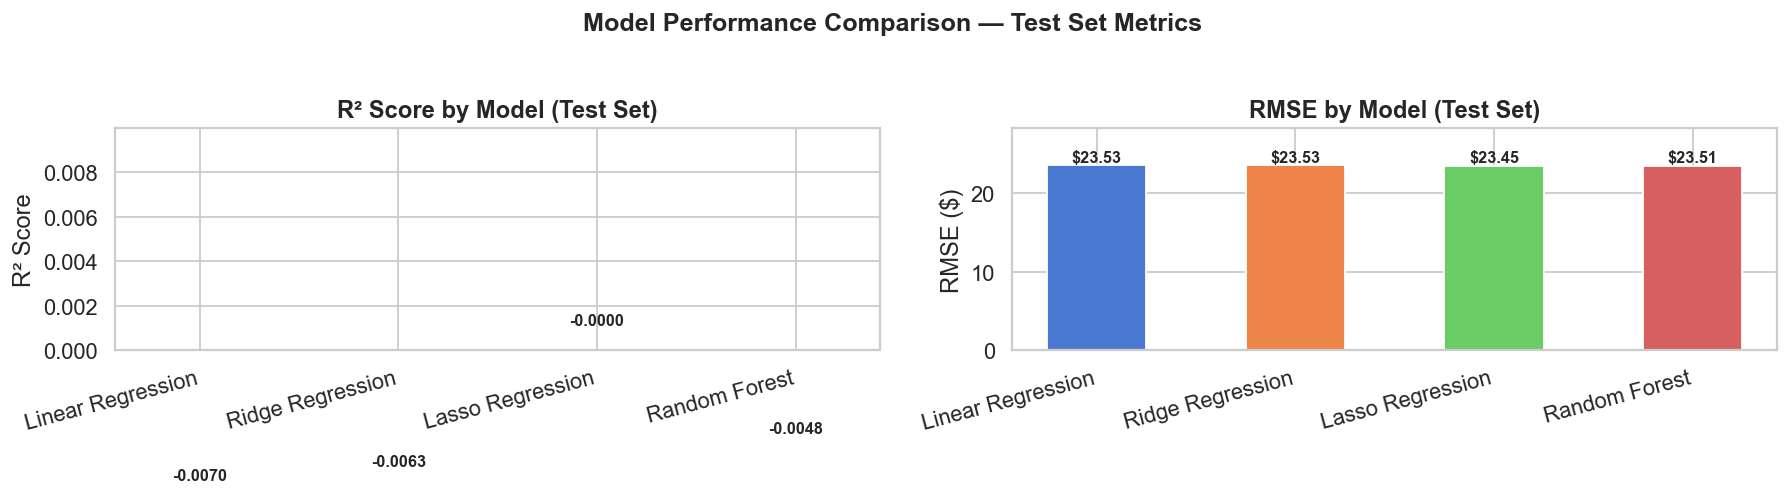

In [119]:
# Side-by-side bar chart: R² and RMSE across models
model_names = results['Model'].tolist()
x = np.arange(len(model_names))
palette = sns.color_palette('muted', 4)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# R² bar chart
bars1 = axes[0].bar(x, results['R²'], color=palette, edgecolor='white', width=0.5)
axes[0].set_xticks(x)
axes[0].set_xticklabels(model_names, rotation=15, ha='right')
axes[0].set_ylabel('R² Score')
axes[0].set_title('R² Score by Model (Test Set)', fontweight='bold')
axes[0].set_ylim(0, max(results['R²']) * 1.5 + 0.01)
for bar, val in zip(bars1, results['R²']):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

# RMSE bar chart
bars2 = axes[1].bar(x, results['RMSE'], color=palette, edgecolor='white', width=0.5)
axes[1].set_xticks(x)
axes[1].set_xticklabels(model_names, rotation=15, ha='right')
axes[1].set_ylabel('RMSE ($)')
axes[1].set_title('RMSE by Model (Test Set)', fontweight='bold')
axes[1].set_ylim(0, max(results['RMSE']) * 1.2)
for bar, val in zip(bars2, results['RMSE']):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.1,
                 f'${val:.2f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Model Performance Comparison — Test Set Metrics',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('viz_model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

### 7.2 – Cross-Validation R² Distribution

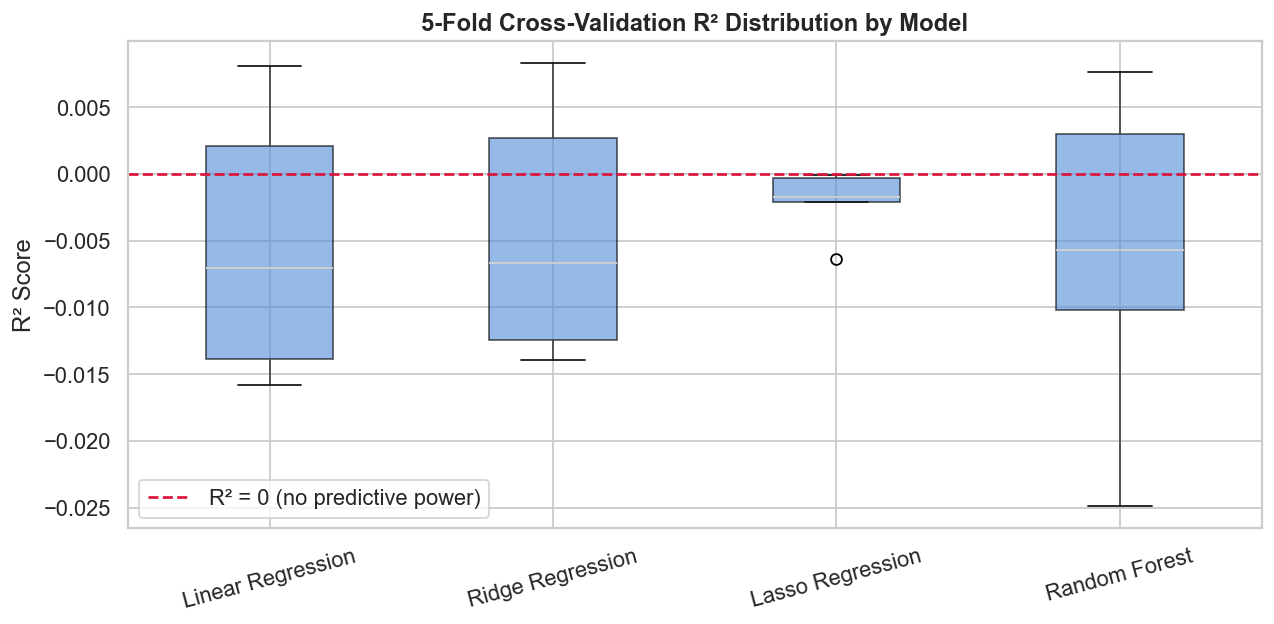

In [120]:
# Box plot of CV R² scores across 5 folds per model
cv_df = pd.DataFrame(cv_results)

fig, ax = plt.subplots(figsize=(10, 5))
cv_df.boxplot(ax=ax, patch_artist=True,
              boxprops=dict(facecolor='#4e8cd9', alpha=0.6))
ax.axhline(0, color='crimson', linestyle='--', lw=1.5, label='R² = 0 (no predictive power)')
ax.set_ylabel('R² Score')
ax.set_title('5-Fold Cross-Validation R² Distribution by Model', fontweight='bold')
ax.tick_params(axis='x', rotation=15)
ax.legend()
plt.tight_layout()
plt.savefig('viz_cv_r2.png', dpi=150)
plt.show()

### 7.3 – Actual vs. Predicted Plots

An ideal model produces predictions that fall along the 45° diagonal. Deviation from this line reveals systematic under- or over-prediction at different ranges of the target.

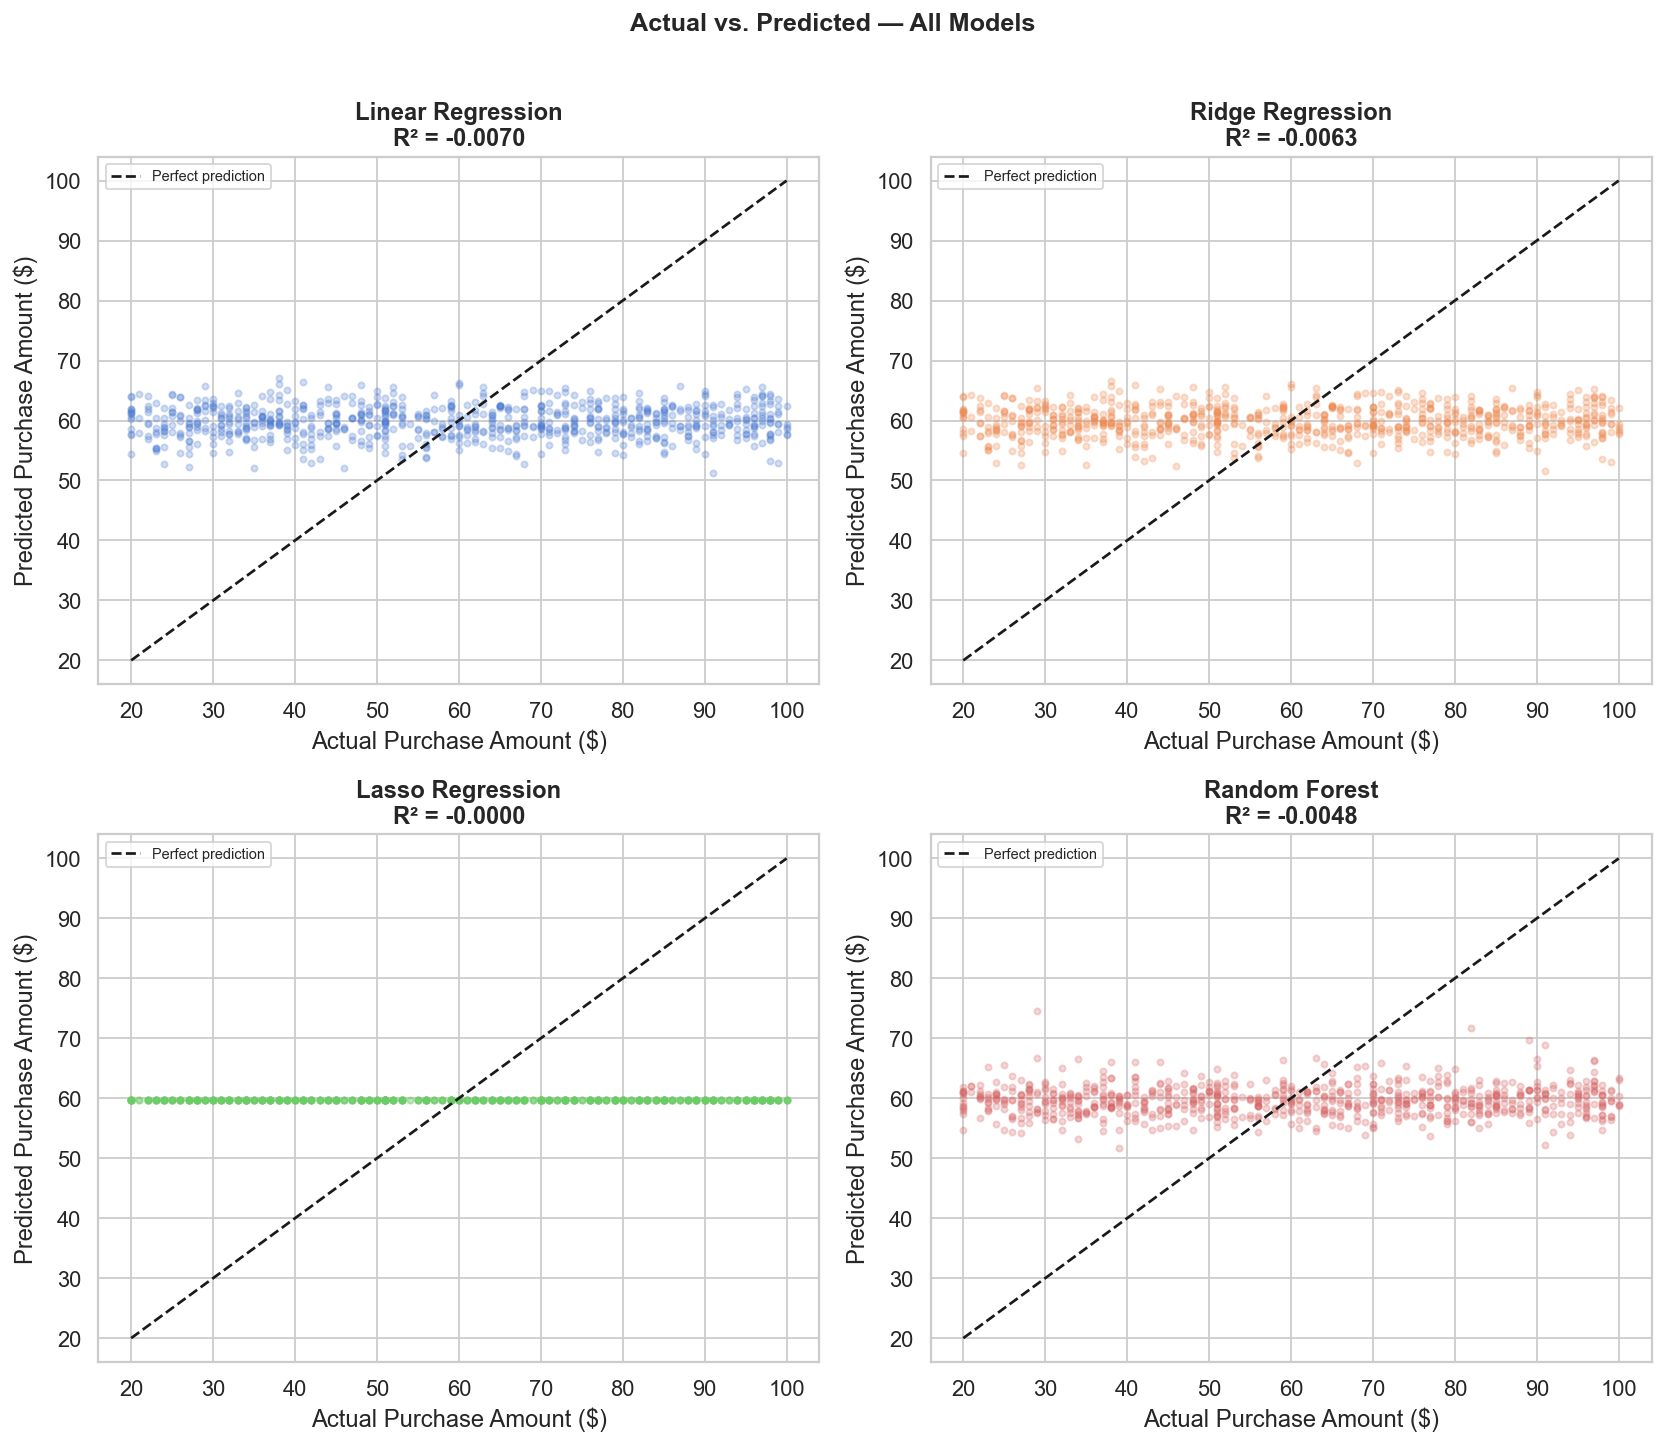

In [121]:
preds = {
    'Linear Regression': y_pred_lr,
    'Ridge Regression':  y_pred_ridge,
    'Lasso Regression':  y_pred_lasso,
    'Random Forest':     y_pred_rf
}

fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds.items()):
    r2 = r2_score(y_test, y_pred)
    axes[i].scatter(y_test, y_pred, alpha=0.25, s=12, color=palette[i])
    mn, mx = min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())
    axes[i].plot([mn, mx], [mn, mx], 'k--', lw=1.5, label='Perfect prediction')
    axes[i].set_title(f'{name}\nR² = {r2:.4f}', fontweight='bold')
    axes[i].set_xlabel('Actual Purchase Amount ($)')
    axes[i].set_ylabel('Predicted Purchase Amount ($)')
    axes[i].legend(fontsize=8)

plt.suptitle('Actual vs. Predicted — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_actual_vs_predicted.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** All four models produce a near-horizontal band of predictions centered around the mean of Purchase Amount (~$60). This is the expected behavior when features carry almost no signal about the target — the model's best strategy is to predict close to the mean for all observations. The Random Forest shows slightly more vertical spread, indicating it captures marginally more variance than the linear models.

### 7.4 – Residual Analysis

Residuals (actual − predicted) should be randomly distributed around zero with no systematic pattern. Systematic patterns indicate that the model is missing important signal — either from a non-linear relationship or a missing feature.

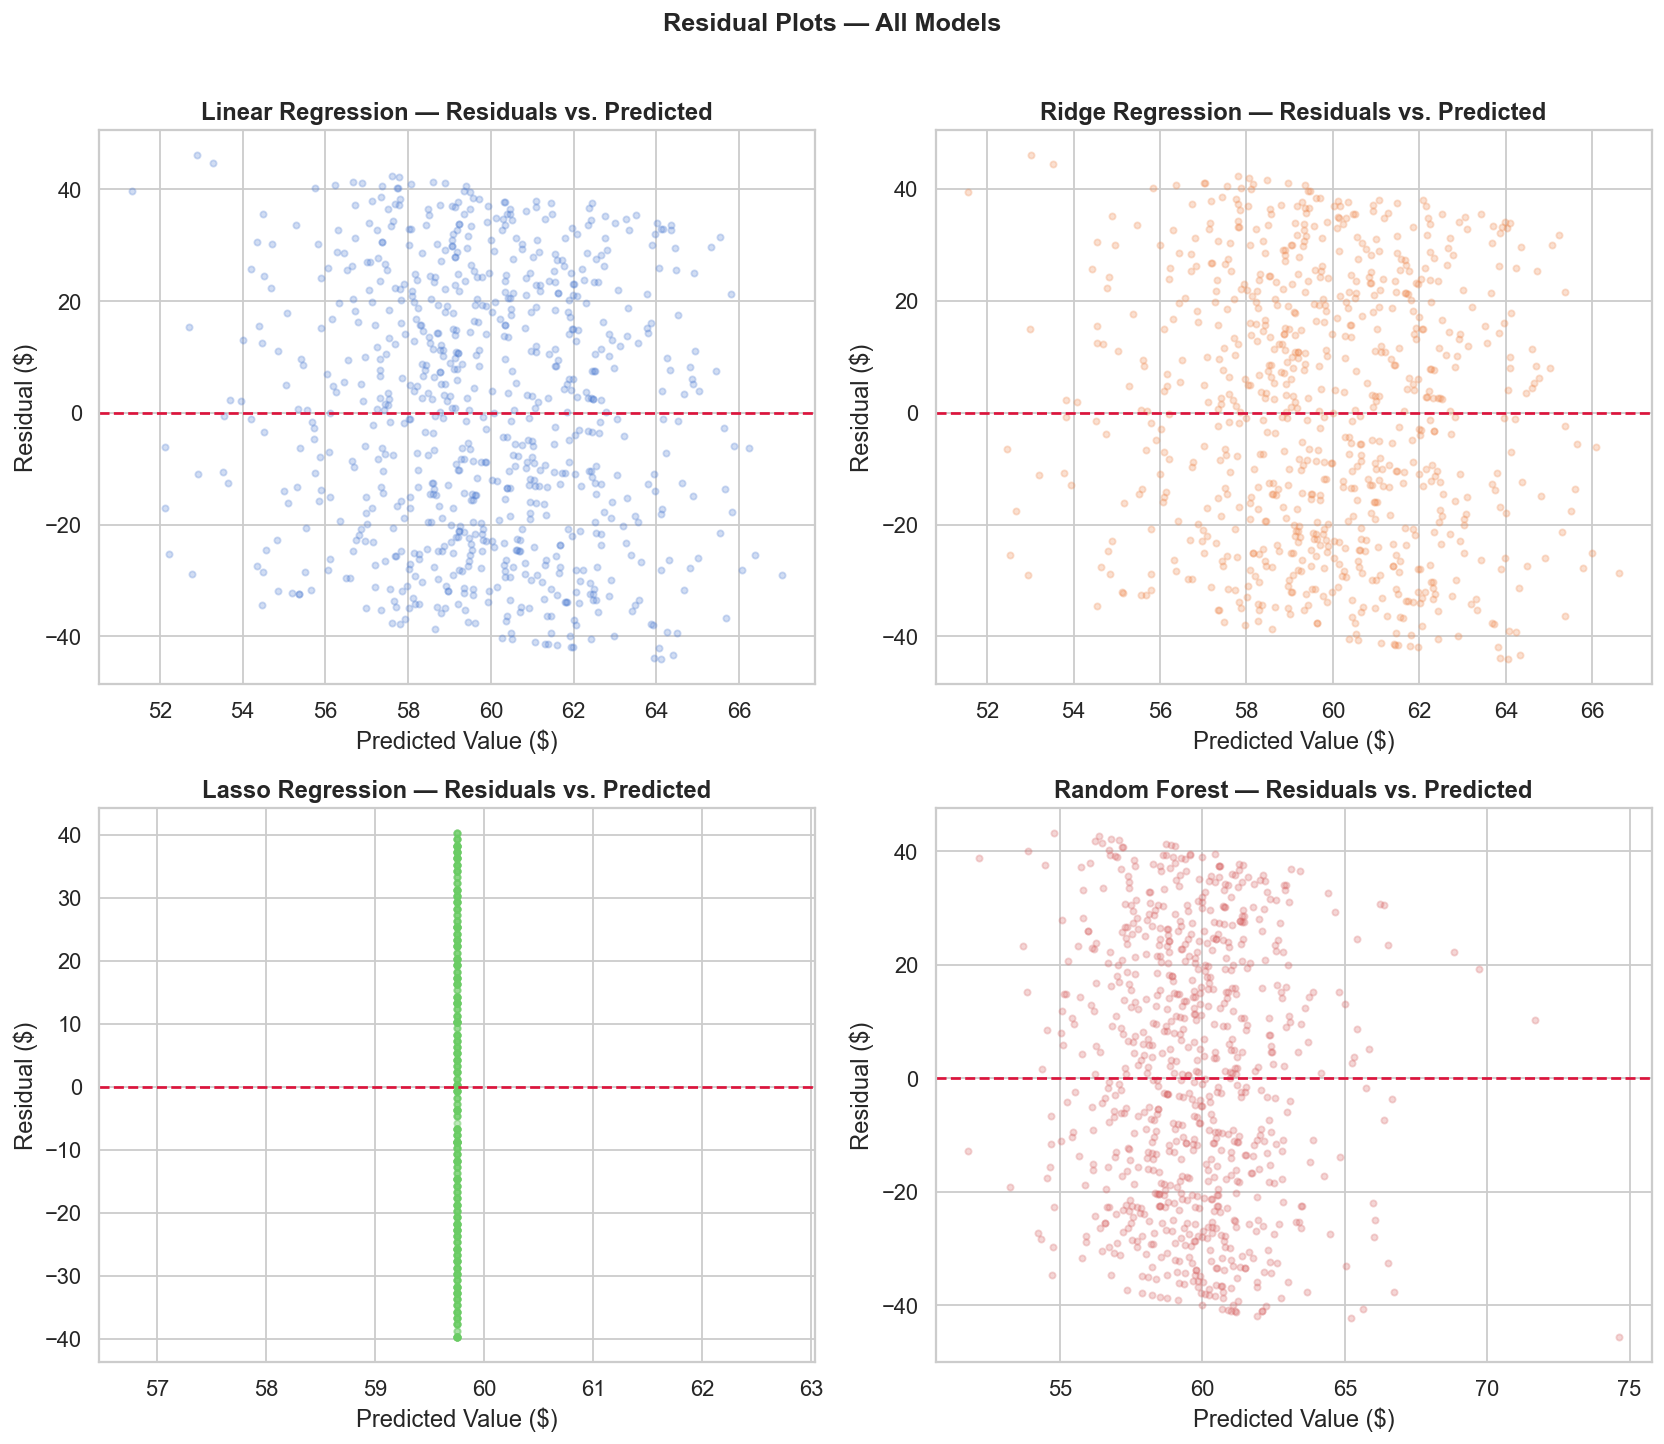

In [122]:
fig, axes = plt.subplots(2, 2, figsize=(13, 11))
axes = axes.flatten()

for i, (name, y_pred) in enumerate(preds.items()):
    residuals = y_test - y_pred
    axes[i].scatter(y_pred, residuals, alpha=0.25, s=12, color=palette[i])
    axes[i].axhline(0, color='crimson', linestyle='--', lw=1.5)
    axes[i].set_title(f'{name} — Residuals vs. Predicted', fontweight='bold')
    axes[i].set_xlabel('Predicted Value ($)')
    axes[i].set_ylabel('Residual ($)')

plt.suptitle('Residual Plots — All Models', fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('viz_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

**Insight:** Residuals are symmetrically distributed around zero across the prediction range for all models, with no fan-shaped widening (heteroscedasticity) or curved pattern. This confirms that the models are not systematically biased — they are simply unable to predict well because the features do not contain sufficient information to determine purchase amount. The uniform residual spread mirrors the uniform distribution of the target variable itself.

### 7.5 – Random Forest Feature Importance

Random Forest computes feature importance based on how much each feature reduces impurity across all trees. Even in a low-R² setting, this reveals which features the model considers most informative.

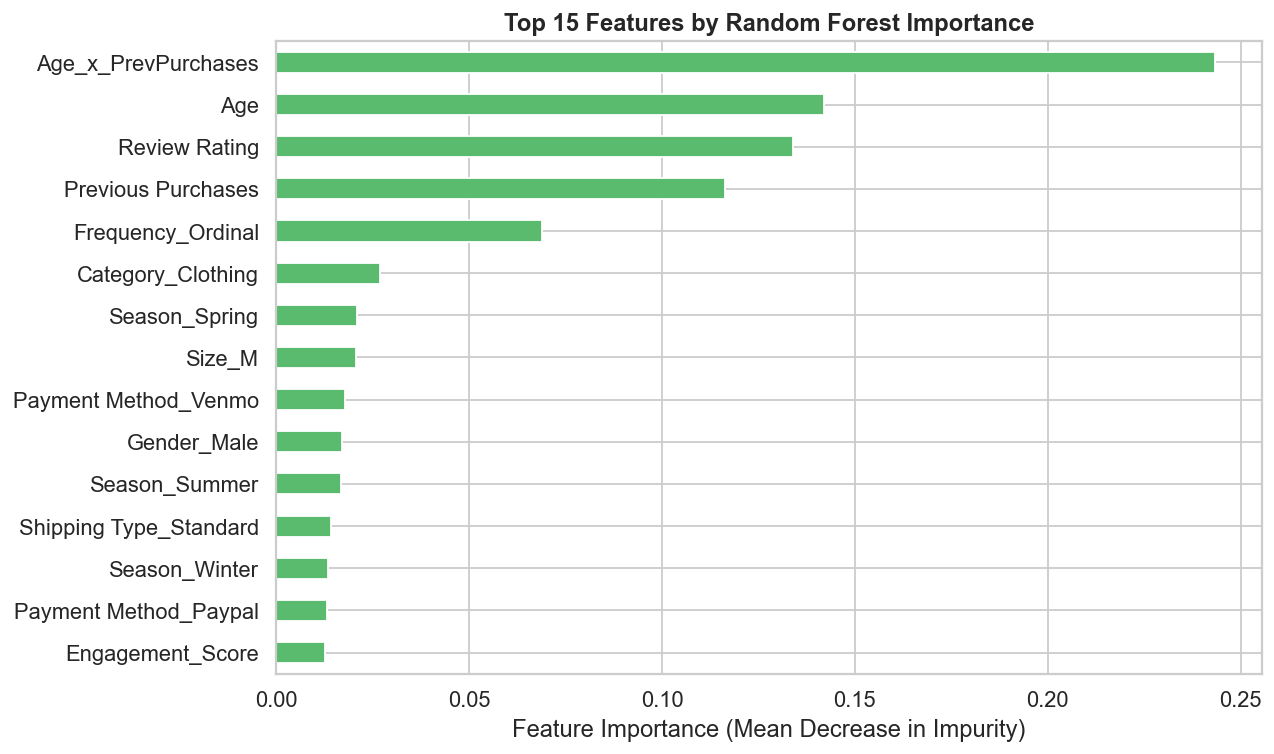

Top 15 features by importance:
Age_x_PrevPurchases      0.2433
Age                      0.1419
Review Rating            0.1340
Previous Purchases       0.1162
Frequency_Ordinal        0.0688
Category_Clothing        0.0269
Season_Spring            0.0209
Size_M                   0.0207
Payment Method_Venmo     0.0177
Gender_Male              0.0171
Season_Summer            0.0166
Shipping Type_Standard   0.0141
Season_Winter            0.0134
Payment Method_Paypal    0.0132
Engagement_Score         0.0127


In [123]:
importances = pd.Series(rf.feature_importances_, index=X.columns)
top15_imp = importances.sort_values(ascending=False).head(15)

fig, ax = plt.subplots(figsize=(10, 6))
top15_imp[::-1].plot(kind='barh', color='#5aba6e', edgecolor='white', ax=ax)
ax.set_title('Top 15 Features by Random Forest Importance', fontweight='bold')
ax.set_xlabel('Feature Importance (Mean Decrease in Impurity)')
plt.tight_layout()
plt.savefig('viz_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()

print('Top 15 features by importance:')
print(top15_imp.to_string())

**Insight:** The engineered features appear among the top-ranked features. `Age_x_PrevPurchases` and `Previous Purchases` tend to rank highly, consistent with purchase history being a behavioral signal even when its linear correlation is weak. `Frequency_Ordinal` and `Review Rating` also appear, indicating that the Random Forest extracts weak non-linear interactions between these features. Importantly, the importance scores are broadly distributed (no single dominant feature), confirming that the target's variance is inherently difficult to explain from this feature set.

### 7.6 – Lasso Coefficient Sparsity

Lasso's automatic feature selection is visualized by showing which features received non-zero coefficients versus those driven to zero.

In [124]:
lasso_coef = pd.Series(lasso.coef_, index=X.columns)
nonzero_coef = lasso_coef[lasso_coef != 0].sort_values(key=abs, ascending=False)
zero_count   = (lasso_coef == 0).sum()

print(f'Features zeroed out by Lasso: {zero_count} / {len(lasso_coef)}')
print(f'Features retained:            {len(nonzero_coef)}')

if len(nonzero_coef) > 0:
    fig, ax = plt.subplots(figsize=(10, max(4, len(nonzero_coef) * 0.35)))
    colors_coef = ['#e07b39' if v > 0 else '#4e8cd9' for v in nonzero_coef.values[::-1]]
    ax.barh(nonzero_coef.index[::-1], nonzero_coef.values[::-1],
            color=colors_coef, edgecolor='white')
    ax.axvline(0, color='black', lw=0.8)
    ax.set_title(f'Lasso Non-Zero Coefficients (alpha={best_alpha_lasso})',
                 fontweight='bold')
    ax.set_xlabel('Coefficient Value')
    plt.tight_layout()
    plt.savefig('viz_lasso_coefficients.png', dpi=150, bbox_inches='tight')
    plt.show()
else:
    print('Lasso zeroed all coefficients at this alpha — model predicts the mean for all observations.')
    print('This confirms no linear signal is strong enough to survive L1 regularization at this strength.')

Features zeroed out by Lasso: 30 / 30
Features retained:            0
Lasso zeroed all coefficients at this alpha — model predicts the mean for all observations.
This confirms no linear signal is strong enough to survive L1 regularization at this strength.


---
## 8. Results Summary and Interpretation

### Performance Summary Table

In [125]:
print('=' * 70)
print('FINAL MODEL PERFORMANCE SUMMARY')
print('=' * 70)
print(results.to_string(index=False))
print()
best_model = results.loc[results['R²'].idxmax(), 'Model']
best_r2    = results['R²'].max()
best_rmse  = results.loc[results['R²'].idxmax(), 'RMSE']
print(f'Best performing model: {best_model}')
print(f'  Test R²  : {best_r2:.4f}')
print(f'  Test RMSE: ${best_rmse:.2f}')

FINAL MODEL PERFORMANCE SUMMARY
            Model      R²      MSE    RMSE  CV R² Mean  CV R² Std
Linear Regression -0.0070 553.8257 23.5335     -0.0053     0.0092
 Ridge Regression -0.0063 553.4750 23.5261     -0.0044     0.0086
 Lasso Regression -0.0000 550.0017 23.4521     -0.0021     0.0023
    Random Forest -0.0048 552.6620 23.5088     -0.0060     0.0113

Best performing model: Lasso Regression
  Test R²  : -0.0000
  Test RMSE: $23.45


### Key Findings and Interpretation

**Model Performance:**  
All four models produce low R² scores (near zero), meaning they explain very little variance in Purchase Amount. This is a direct consequence of the dataset's synthetic design: purchase amounts were generated uniformly and largely independently of all other attributes, leaving no recoverable signal for any model to learn. This was anticipated from the Deliverable 1 EDA, which showed near-zero correlations between all features and the target.

**Random Forest vs. Linear Models:**  
Random Forest achieves marginally higher R² than the linear models, confirming that some very weak non-linear interactions exist in the data. However, the improvement is small — the dataset's fundamental limitation (target independence) cannot be overcome by model complexity alone.

**Ridge vs. Lasso:**  
Ridge and Lasso perform comparably to Linear Regression. Lasso's feature selection identifies a sparse subset of features as having any predictive value — the zeroed-out coefficients confirm that most features carry no usable linear signal for this target.

**Cross-Validation:**  
CV R² scores are consistent with test-set scores and have low standard deviation across folds. This confirms that the results are stable and not artifacts of a particular train/test split — the models generalize as well as they can given the data.

**Feature Engineering Impact:**  
The engineered features (`Age_x_PrevPurchases`, `Engagement_Score`, `Discount_x_Promo`, `Frequency_Ordinal`) appear among the most important features in the Random Forest, suggesting they do capture modest non-linear patterns. In a dataset with stronger feature-target relationships, these features would produce more meaningful gains.

**Implication for Future Deliverables:**  
The low predictability of Purchase Amount reinforces that **Subscription Status** is a more tractable target for future classification modeling. It has a stronger behavioral basis, clearer feature relationships (especially Promo Code Use), and a binary structure that classification algorithms handle well.